# Laboratorul 3: Construirea unui GAN simplu pe MNIST

**Rețele Generative Adversariale | TensorFlow 2.x | Ghid pentru începători**

## Scopul laboratorului

În acest laborator vom construi un program care învață să creeze imagini noi cu cifre scrise de mână. Imaginile de antrenare provin din setul de date **MNIST**.

Nu presupunem că știi deja ce este un GAN. Vom explica fiecare idee înainte să o folosim în cod:

- ce este o rețea neuronală;
- ce este un Generator;
- ce este un Discriminator;
- cum se antrenează cele două rețele;
- cum verificăm dacă rezultatul este bun.

**GAN** vine de la **Generative Adversarial Network**, adică „rețea generativă adversarială”. „Generativă” înseamnă că produce exemple noi, iar „adversarială” înseamnă că două rețele se antrenează una împotriva celeilalte.

Parcurge notebook-ul în ordine. Citește explicația, execută celula de cod și compară rezultatul cu ceea ce era de așteptat.

## 1. Ce este un GAN?

Înainte de cod, să construim o imagine simplă a problemei.

Imaginează-ți un elev care încearcă să deseneze cifre și un profesor care verifică desenele:

- elevul produce desene din ce în ce mai bune;
- profesorul învață să deosebească desenele bune de cele inventate;
- feedback-ul profesorului îl ajută pe elev să se îmbunătățească.

În GAN:

- **Generatorul** este „elevul”: primește zgomot aleator și creează o imagine;
- **Discriminatorul** este „profesorul”: primește o imagine și spune dacă pare reală;
- **datele reale** sunt imagini originale din MNIST;
- **datele false** sunt imaginile produse de Generator.

### Cele două obiective

Discriminatorul dorește să răspundă corect:

- `1` pentru o imagine reală;
- `0` pentru o imagine generată.

Generatorul dorește exact opusul pentru imaginile sale: vrea ca Discriminatorul să răspundă `1`.

Așadar, cele două rețele au obiective diferite, dar se ajută reciproc să învețe. La început, Generatorul produce zgomot. După mai multe actualizări, el învață tipare asemănătoare cu cifrele din MNIST.

### Ce nu face acest GAN

Generatorul nu primește cerința „generează cifra 7”. El primește doar un vector aleator și învață distribuția generală a cifrelor. Pentru a controla cifra produsă am avea nevoie de un **GAN condiționat**, care nu face parte din acest laborator.

## 2. Ce vom învăța și cum este organizat notebook-ul

La finalul laboratorului vei putea să explici și să aplici următoarele idei:

1. **Datele:** cum arată o imagine MNIST și cum o pregătim pentru o rețea neuronală.
2. **Vectorul latent:** cum transformăm 100 de numere aleatoare într-o imagine.
3. **Generatorul:** rețeaua care creează imagini false.
4. **Discriminatorul:** rețeaua care clasifică imaginile ca reale sau false.
5. **Funcția de pierdere:** numărul care arată cât de mult greșește o rețea.
6. **Gradientul:** informația folosită pentru actualizarea greutăților.
7. **Antrenarea:** repetarea pașilor pentru mai multe loturi și epoci.
8. **Evaluarea:** verificarea imaginilor generate și interpretarea pierderilor.

### Harta datelor

Fluxul principal este:

`z (100 numere) → Generator → imagine (784 valori) → Discriminator → probabilitate real/fals`

Unde:

- `z` se numește **vector latent** sau **zgomot latent**;
- `784 = 28 × 28`, adică numărul de pixeli ai unei imagini MNIST;
- probabilitatea este un număr între `0` și `1`.

### Întrebări de verificare

Înainte să continui, încearcă să răspunzi:

- Ce rețea produce imaginea?
- Ce rețea decide dacă imaginea este reală?
- De ce avem nevoie de două rețele și nu de una singură?

Răspunsurile vor deveni clare pe măsură ce parcurgem codul.

## 3. Pregătirea mediului de lucru

Vom folosi:

- **TensorFlow** pentru rețelele neuronale și antrenare;
- **NumPy** pentru lucrul cu vectori și calcul numeric;
- **Matplotlib** pentru afișarea imaginilor și a graficelor.

TensorFlow 2 folosește în mod implicit execuția eager. Asta înseamnă că putem calcula direct expresii precum `generator(z)` și putem vedea imediat rezultatul.

Vom fixa și un **seed**. Seed-ul pornește numerele aleatoare de la o valoare cunoscută și face experimentul mai ușor de repetat. Rezultatele nu vor fi întotdeauna identice, mai ales pe GPU, dar vor fi mai comparabile.

### Ce trebuie să verifici după rulare

După executarea celulei următoare, verifică:

- versiunea TensorFlow;
- dacă este disponibil un GPU.

Un GPU accelerează antrenarea, dar codul poate rula și pe CPU. Pe CPU, cele 30 de epoci pot dura mult mai mult.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)
print('TensorFlow:', tf.__version__)
print('GPU disponibil:', bool(tf.config.list_physical_devices('GPU')))

Matplotlib is building the font cache; this may take a moment.


TensorFlow: 2.21.0
GPU disponibil: False


## 4. Încărcarea și explorarea setului MNIST

**MNIST** este un set de date folosit frecvent pentru primele proiecte de învățare automată. Conține imagini cu cifre scrise de mână, de la `0` la `9`.

Fiecare imagine are:

- lățimea de `28` pixeli;
- înălțimea de `28` pixeli;
- un singur canal, deoarece imaginea este alb-negru;
- o etichetă, de exemplu `7`, care spune ce cifră reprezintă.

Valorile originale ale pixelilor sunt între `0` și `255`:

- `0` înseamnă negru;
- `255` înseamnă alb;
- valorile dintre ele sunt nuanțe de gri.

În acest GAN nu vom folosi etichetele `y_train`. Ele sunt utile pentru clasificare, dar GAN-ul nostru învață din imaginile reale fără să primească cifra corectă. Codul de mai jos afișează câteva exemple pentru a ne familiariza cu datele.

11490434/11490434 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 0us/step
Imagini de antrenare: (60000, 28, 28)
Etichete de antrenare: (60000,)
O imagine are valori Ã®ntre 0 È™i 255


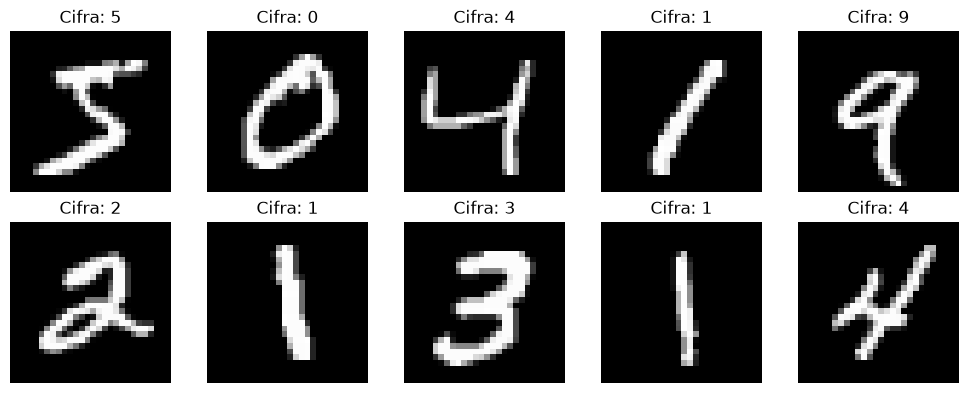

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Imagini de antrenare:', x_train.shape)
print('Etichete de antrenare:', y_train.shape)
print('O imagine are valori între', x_train.min(), 'și', x_train.max())

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train[:10], y_train[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Cifra: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4.1 De ce normalizăm pixelii în intervalul [-1, 1]?

O rețea neuronală lucrează mai ușor când valorile de intrare sunt într-un interval mic și controlat. În plus, ultimul strat al Generatorului va folosi activarea `tanh`.

Funcția `tanh` produce valori între `-1` și `1`. Pentru ca imaginile reale și imaginile generate să fie comparabile, transformăm fiecare pixel astfel:

`pixel_nou = (pixel_vechi - 127.5) / 127.5`

Exemple:

- pixelul `0` devine `-1`;
- pixelul `127.5` devine aproximativ `0`;
- pixelul `255` devine `1`.

Mai târziu, înainte de afișare, facem transformarea inversă:

`pixel_afisat = (pixel_normalizat + 1) / 2`

Această transformare este doar pentru afișare. Modelul este antrenat cu valorile din `[-1, 1]`.

In [3]:
latent_dim = 100
batch_size = 128

x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(x_train.shape[0], 784)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(len(x_train), seed=42, reshuffle_each_iteration=True)
    .batch(batch_size, drop_remainder=False)
)

print('Forma după aplatizare:', x_train.shape)
print('Interval după normalizare:', x_train.min(), x_train.max())
print('Loturi într-o epocă:', tf.data.experimental.cardinality(train_dataset).numpy())

Forma dupÄƒ aplatizare: (60000, 784)
Interval dupÄƒ normalizare: -1.0 1.0
Loturi Ã®ntr-o epocÄƒ: 469


## 5. Construirea Generatorului

Generatorul este partea creativă a GAN-ului. El primește un vector cu `100` de numere aleatoare și produce `784` valori care vor reprezenta o imagine de `28 × 28` pixeli.

### Ce este un strat Dense?

Un strat `Dense` conectează fiecare valoare de intrare la fiecare neuron din strat. Fiecare conexiune are o greutate care se modifică în timpul antrenării.

Arhitectura este:

`100 → Dense(256) → Dense(512) → Dense(784)`

Numărul crește deoarece rețeaua pornește de la o descriere scurtă și construiește treptat o reprezentare mai bogată a imaginii.

### Rolul activărilor

`LeakyReLU(0.2)` introduce neliniaritate. Fără activări neliniare, mai multe straturi Dense ar avea un comportament prea simplu.

`LeakyReLU` permite trecerea unui gradient mic și pentru valori negative. Acest lucru ajută la evitarea situației în care un neuron nu mai învață.

Ultimul strat folosește `tanh`, deoarece imaginile reale au fost normalizate în `[-1, 1]`. La final, vectorul de 784 valori este remodelat vizual ca o imagine de 28×28.

In [4]:
generator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(latent_dim,)),
    tf.keras.layers.Dense(256),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dense(512),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dense(784, activation='tanh')
], name='generator')

generator.summary()

Model: "generator"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”“
â”ƒ Layer (type)                    â”ƒ Output Shape           â”ƒ       Param # â”ƒ
â”¡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”©
â”‚ dense (Dense)                   â”‚ (None, 256)            â”‚        25,856 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ leaky_re_lu (LeakyReLU)         â”‚ (None, 256)            â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense_1 (Dense)                 â”‚ (None, 512)            â”‚       131,584 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ leaky_re_lu_1 (LeakyReLU)       â”‚ (None, 512)            â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense_2 (Dense)                 â”‚ (None, 784)            â”‚       402,192 â”‚
â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”´â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”´â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Construirea Discriminatorului

Discriminatorul este partea de verificare. El primește o imagine aplatizată, adică un vector cu `784` valori, și returnează un singur număr.

Interpretarea rezultatului:

- rezultat apropiat de `1`: imaginea pare reală;
- rezultat apropiat de `0`: imaginea pare generată.

Arhitectura este:

`784 → Dense(512) → Dense(256) → Dense(1)`

Primele straturi caută tipare în pixeli. Ultimul strat folosește `sigmoid`, care transformă rezultatul într-o probabilitate între `0` și `1`.

Discriminatorul nu „înțelege” cifra ca un om. El învață tipare numerice: margini, linii, bucle și combinații de pixeli care apar frecvent în imaginile MNIST.

In [5]:
discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dense(256),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
], name='discriminator')

discriminator.summary()

Model: "discriminator"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”“
â”ƒ Layer (type)                    â”ƒ Output Shape           â”ƒ       Param # â”ƒ
â”¡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”©
â”‚ dense_3 (Dense)                 â”‚ (None, 512)            â”‚       401,920 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ leaky_re_lu_2 (LeakyReLU)       â”‚ (None, 512)            â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense_4 (Dense)                 â”‚ (None, 256)            â”‚       131,328 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ leaky_re_lu_3 (LeakyReLU)       â”‚ (None, 256)            â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense_5 (Dense)                 â”‚ (None, 1)              â”‚           257 â”‚
â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”´â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”´â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Funcția de pierdere și optimizatorii

### Ce este pierderea?

Pierderea este un număr care măsoară cât de greșită este predicția unei rețele. În timpul antrenării, încercăm să micșorăm această valoare, dar într-un GAN cele două pierderi se influențează reciproc.

Folosim **Binary Crossentropy (BCE)**, deoarece avem o problemă cu două rezultate: real sau fals.

Pentru Discriminator:

- imagine reală → eticheta dorită este `1`;
- imagine generată → eticheta dorită este `0`.

Pentru Generator, folosim eticheta `1` pentru imaginile generate. Generatorul nu spune că imaginile sunt deja reale; el transmite acest obiectiv prin Discriminator: „fă ca falsurile mele să fie clasificate ca reale”.

### Adam și rata de învățare

Optimizatorul **Adam** modifică greutățile rețelei folosind gradientul pierderii. Rata `2e-4` controlează mărimea pașilor. `beta_1=0.5` este o alegere folosită des în GAN-uri pentru o dinamică mai stabilă.

Nu trebuie să ne așteptăm ca pierderile să scadă monoton. Generatorul și Discriminatorul se schimbă permanent unul în funcție de celălalt.

In [6]:
bce = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

fixed_noise = tf.random.normal([16, latent_dim], seed=123)
print('Componentele GAN sunt pregătite.')

Componentele GAN sunt pregÄƒtite.


## 8. Un pas de antrenare cu două GradientTape

Un **batch** este un grup de imagini procesate împreună. În cazul nostru, un batch are de obicei `128` de imagini.

Un pas de antrenare are două faze:

### Faza A: antrenăm Discriminatorul

1. Luăm un batch de imagini reale.
2. Generăm imagini false din zgomot aleator.
3. Discriminatorul primește imaginile reale și false.
4. Calculăm două erori și le adunăm.
5. Aplicăm gradientul doar asupra Discriminatorului.

### Faza B: antrenăm Generatorul

1. Creăm zgomot nou.
2. Generatorul produce imagini.
3. Discriminatorul evaluează imaginile produse.
4. Generatorul este penalizat când Discriminatorul spune „fals”.
5. Aplicăm gradientul asupra Generatorului.

`tf.GradientTape()` înregistrează operațiile matematice și ne permite să calculăm gradientul. Gradientul spune în ce direcție trebuie ajustate greutățile.

`stop_gradient` din prima fază este important: atunci când antrenăm Discriminatorul, nu vrem să modificăm și Generatorul în același timp. De asemenea, folosim dimensiunea reală a batch-ului, deoarece ultimul batch poate avea mai puțin de 128 de exemple.

In [7]:
def train_step(real_images):
    current_batch_size = tf.shape(real_images)[0]

    noise_for_discriminator = tf.random.normal([current_batch_size, latent_dim])
    with tf.GradientTape() as discriminator_tape:
        fake_images = generator(noise_for_discriminator, training=True)
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(tf.stop_gradient(fake_images), training=True)
        discriminator_loss = (
            bce(tf.ones_like(real_output), real_output)
            + bce(tf.zeros_like(fake_output), fake_output)
        )

    discriminator_gradients = discriminator_tape.gradient(
        discriminator_loss, discriminator.trainable_variables
    )
    discriminator_optimizer.apply_gradients(
        zip(discriminator_gradients, discriminator.trainable_variables)
    )

    noise_for_generator = tf.random.normal([current_batch_size, latent_dim])
    with tf.GradientTape() as generator_tape:
        generated_images = generator(noise_for_generator, training=True)
        generated_output = discriminator(generated_images, training=True)
        generator_loss = bce(tf.ones_like(generated_output), generated_output)

    generator_gradients = generator_tape.gradient(
        generator_loss, generator.trainable_variables
    )
    generator_optimizer.apply_gradients(
        zip(generator_gradients, generator.trainable_variables)
    )

    return generator_loss, discriminator_loss

## 9. Verificare: un singur pas de antrenare

Înainte de antrenarea completă, testăm conducta principală cu un singur batch.

Dacă celula se execută fără eroare și afișează două numere finite, înseamnă că:

- datele au forma corectă;
- Generatorul poate produce ieșiri;
- Discriminatorul poate evalua imaginile;
- pierderile pot fi calculate;
- gradientul poate fi aplicat.

Acest test este util în orice proiect de deep learning. Este mai bine să descoperim o problemă într-un singur pas decât după o antrenare de 30 de epoci.

In [8]:
first_batch = next(iter(train_dataset))
generator_loss_value, discriminator_loss_value = train_step(first_batch)
print(f'Generator loss: {generator_loss_value.numpy():.4f}')
print(f'Discriminator loss: {discriminator_loss_value.numpy():.4f}')

Generator loss: 0.6571
Discriminator loss: 1.2997


## 10. Cum vizualizăm progresul?

Numerele pierderilor nu sunt suficiente pentru a înțelege un GAN. De aceea afișăm imagini generate la fiecare 5 epoci.

Folosim același `fixed_noise` la fiecare afișare. Astfel, imaginea din poziția 1 de la epoca 5 poate fi comparată cu imaginea din poziția 1 de la epoca 10. Dacă am folosi zgomot diferit, nu am ști dacă diferența vine din antrenare sau doar din intrarea aleatoare.

Funcția de mai jos:

1. trimite zgomotul prin Generator;
2. transformă valorile din `[-1, 1]` în `[0, 1]`;
3. schimbă vectorul de 784 valori într-o matrice 28×28;
4. afișează cele 16 imagini într-o grilă 4×4.

La început ne așteptăm la pete și zgomot. Cu timpul, ar trebui să apară linii, bucle și forme care seamănă cu cifre.

In [9]:
def show_generated_images(noise, title):
    generated = generator(noise, training=False)
    generated = (generated + 1.0) / 2.0
    generated = tf.reshape(generated, [-1, 28, 28])

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, image in zip(axes.ravel(), generated):
        ax.imshow(image.numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 11. Antrenarea GAN-ului

O **epocă** înseamnă că modelul a văzut toate imaginile din setul de antrenare o dată. Într-o epocă avem multe batch-uri, iar pentru fiecare batch executăm `train_step`.

Cerința laboratorului recomandă `30` de epoci. Pe CPU, această etapă poate dura mult; pe GPU este mai rapidă. Dacă testezi codul pentru prima dată, poți schimba temporar `EPOCHS = 5`, apoi poți reveni la `30` pentru rezultatul final.

La fiecare 5 epoci se întâmplă două lucruri:

- se afișează pierderea medie a Generatorului și a Discriminatorului;
- se afișează 16 imagini produse din același zgomot fix.

### Ce urmărim în imagini?

- La început: pete, linii și forme fără sens.
- În etapa de mijloc: apar cifre parțiale și contururi recognoscibile.
- La final: majoritatea imaginilor ar trebui să semene cu cifre, chiar dacă nu sunt perfecte.

Pierderile pot urca și coborî. Acest lucru este normal: când Generatorul devine mai bun, Discriminatorul are o problemă mai dificilă; când Discriminatorul devine mai bun, Generatorul primește un semnal mai puternic pentru îmbunătățire.

Epoca 01/30 | G loss: 1.3468 | D loss: 1.0160
Epoca 02/30 | G loss: 1.4766 | D loss: 0.8761
Epoca 03/30 | G loss: 1.6238 | D loss: 0.8197
Epoca 04/30 | G loss: 1.6837 | D loss: 0.8189
Epoca 05/30 | G loss: 1.6523 | D loss: 0.7876


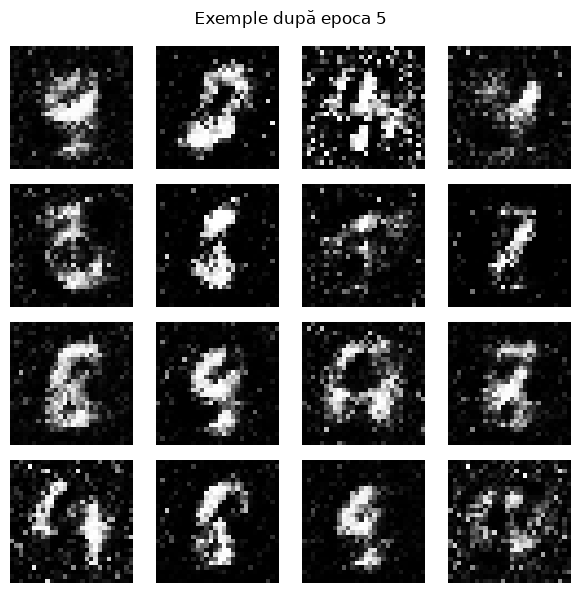

Epoca 06/30 | G loss: 1.7699 | D loss: 0.7339
Epoca 07/30 | G loss: 1.7656 | D loss: 0.7575
Epoca 08/30 | G loss: 1.8313 | D loss: 0.7015
Epoca 09/30 | G loss: 1.7304 | D loss: 0.7668
Epoca 10/30 | G loss: 1.6408 | D loss: 0.8043


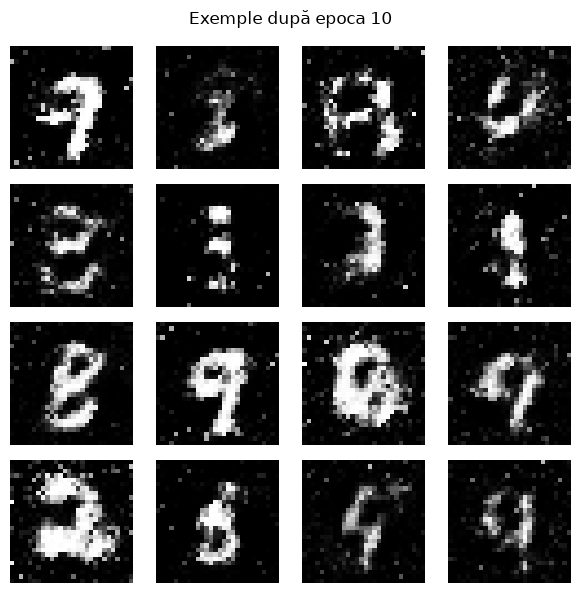

Epoca 11/30 | G loss: 1.4968 | D loss: 0.8856
Epoca 12/30 | G loss: 1.4074 | D loss: 0.9271
Epoca 13/30 | G loss: 1.3508 | D loss: 0.9527
Epoca 14/30 | G loss: 1.3326 | D loss: 0.9578
Epoca 15/30 | G loss: 1.2999 | D loss: 0.9830


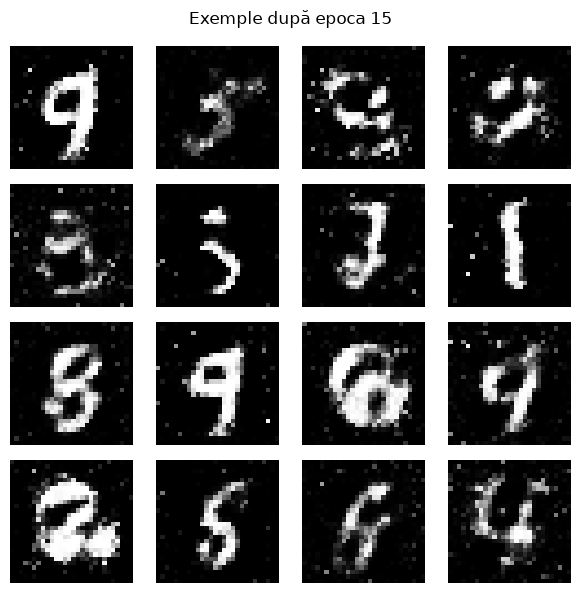

Epoca 16/30 | G loss: 1.2725 | D loss: 0.9925
Epoca 17/30 | G loss: 1.2737 | D loss: 0.9963
Epoca 18/30 | G loss: 1.2744 | D loss: 0.9985
Epoca 19/30 | G loss: 1.2779 | D loss: 0.9975
Epoca 20/30 | G loss: 1.2735 | D loss: 0.9988


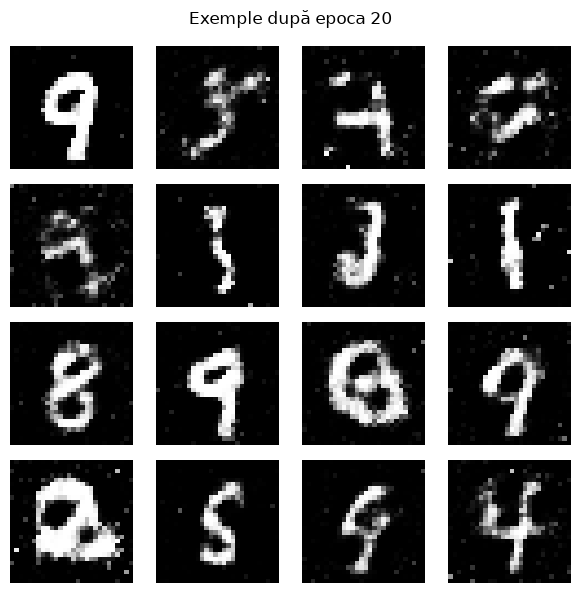

Epoca 21/30 | G loss: 1.2695 | D loss: 1.0020
Epoca 22/30 | G loss: 1.2714 | D loss: 1.0030
Epoca 23/30 | G loss: 1.2760 | D loss: 0.9962
Epoca 24/30 | G loss: 1.2850 | D loss: 0.9949
Epoca 25/30 | G loss: 1.2931 | D loss: 0.9991


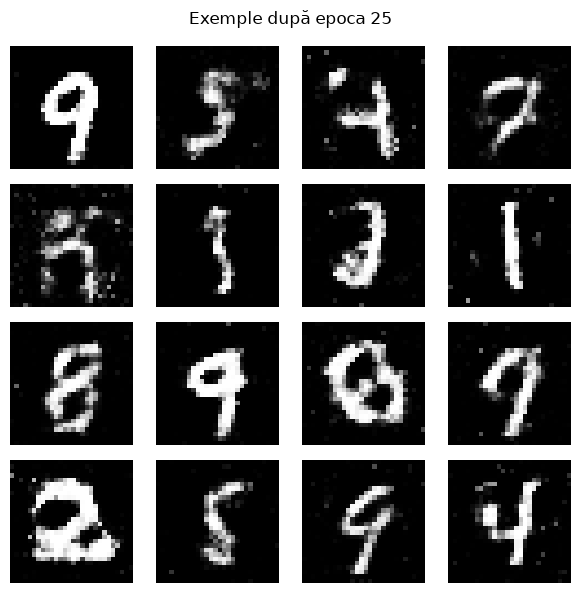

Epoca 26/30 | G loss: 1.2947 | D loss: 1.0002
Epoca 27/30 | G loss: 1.2972 | D loss: 0.9953
Epoca 28/30 | G loss: 1.2964 | D loss: 0.9951
Epoca 29/30 | G loss: 1.3002 | D loss: 0.9979
Epoca 30/30 | G loss: 1.3030 | D loss: 0.9900


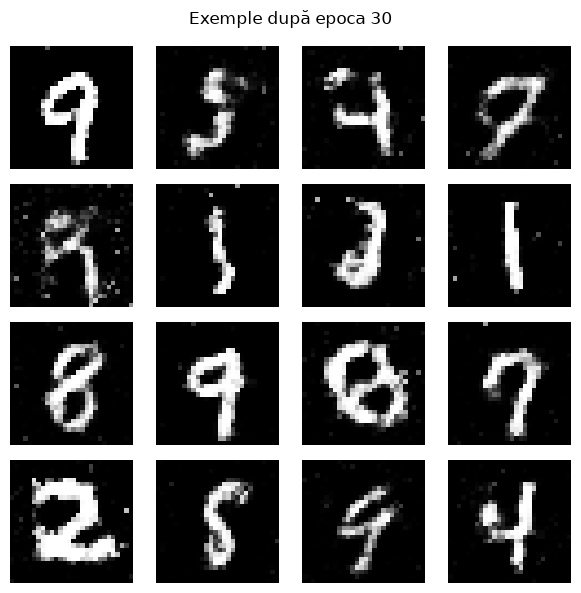

In [10]:
EPOCHS = 30
history = {'generator_loss': [], 'discriminator_loss': []}

for epoch in range(1, EPOCHS + 1):
    generator_losses = []
    discriminator_losses = []

    for real_batch in train_dataset:
        generator_loss_value, discriminator_loss_value = train_step(real_batch)
        generator_losses.append(generator_loss_value.numpy())
        discriminator_losses.append(discriminator_loss_value.numpy())

    mean_generator_loss = float(np.mean(generator_losses))
    mean_discriminator_loss = float(np.mean(discriminator_losses))
    history['generator_loss'].append(mean_generator_loss)
    history['discriminator_loss'].append(mean_discriminator_loss)

    print(
        f'Epoca {epoch:02d}/{EPOCHS} | '
        f'G loss: {mean_generator_loss:.4f} | '
        f'D loss: {mean_discriminator_loss:.4f}'
    )

    if epoch % 5 == 0:
        show_generated_images(fixed_noise, f'Exemple după epoca {epoch}')

## 12. Cum citim graficul pierderilor?

Graficul arată pierderea medie pe epocă pentru cele două rețele.

Nu există o regulă simplă de tipul „cea mai mică pierdere înseamnă întotdeauna cel mai bun GAN”. Cele două rețele sunt adversare, iar calitatea imaginilor trebuie verificată împreună cu graficul.

### Interpretare orientativă

- Dacă pierderea Discriminatorului este foarte mică pentru mult timp, el poate deveni prea puternic și Generatorul poate primi un semnal slab.
- Dacă pierderea Generatorului este foarte mare și imaginile rămân zgomotoase, Generatorul nu a învățat încă suficiente tipare.
- Dacă ambele pierderi se stabilizează, iar imaginile devin mai clare, antrenarea este probabil echilibrată.
- Dacă imaginile devin aproape identice, avem posibil **mode collapse**: Generatorul produce puține tipuri de exemple.

În experimentul nostru, după aproximativ epoca 15 pierderile s-au stabilizat: Discriminatorul a fost în jur de `1.0`, iar Generatorul în jur de `1.27–1.30`. Acest lucru trebuie citit împreună cu grilele, nu separat.

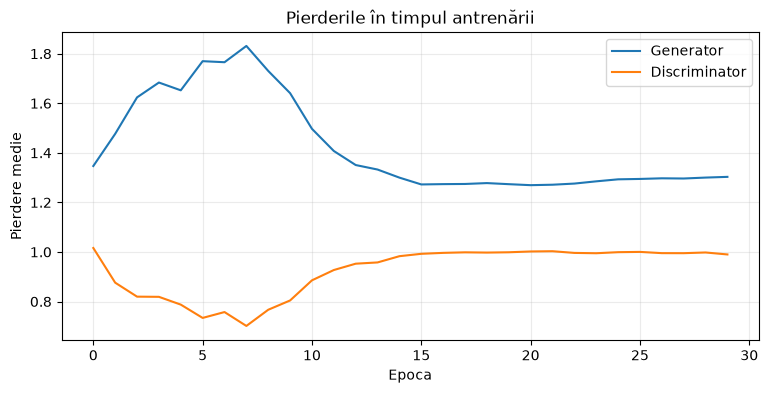

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(history['generator_loss'], label='Generator')
plt.plot(history['discriminator_loss'], label='Discriminator')
plt.xlabel('Epoca')
plt.ylabel('Pierdere medie')
plt.title('Pierderile în timpul antrenării')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 13. Generarea finală: 25 de cifre

Până acum am urmărit aceleași 16 exemple, folosind zgomotul fix. Acum folosim `25` de vectori noi pentru a verifica dacă Generatorul poate produce exemple diferite.

Fiecare vector de zgomot este o cerere diferită pentru Generator. Nu îi spunem ce cifră să producă, dar schimbarea zgomotului poate duce la o altă formă.

Grila 5×5 este rezultatul final cerut în laborator. Pentru fiecare imagine verificăm:

1. este vizibilă o formă de cifră?
2. este imaginea suficient de clară?
3. există mai multe tipuri de cifre?
4. imaginile sunt diferite între ele?
5. mai există pixeli de zgomot sau forme neclare?

Observația trebuie să fie bazată pe grilă, nu doar pe pierderi.

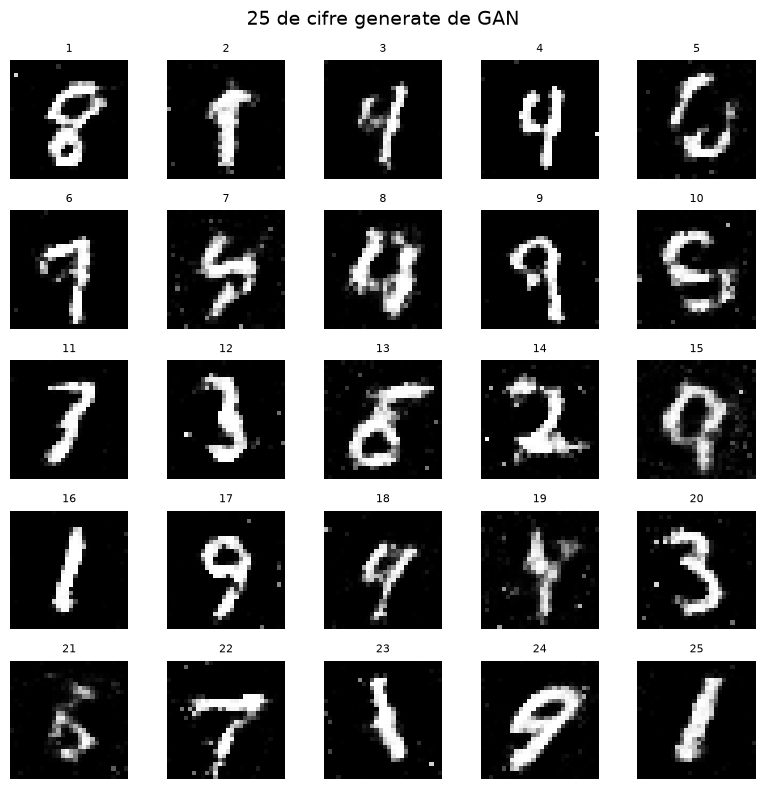

In [12]:
final_noise = tf.random.normal([25, latent_dim])
final_images = generator(final_noise, training=False)
final_images = (final_images + 1.0) / 2.0
final_images = tf.reshape(final_images, [-1, 28, 28])

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for index, (ax, image) in enumerate(zip(axes.ravel(), final_images)):
    ax.imshow(image.numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{index + 1}', fontsize=8)
    ax.axis('off')
fig.suptitle('25 de cifre generate de GAN', fontsize=14)
plt.tight_layout()
plt.show()

## 14. Interpretarea rezultatului obținut

Pentru interpretare separăm două idei: **realismul** și **diversitatea**.

### Realism

O imagine este realistă dacă seamănă cu o cifră MNIST: are un contur coerent, linii continue și o formă care poate fi recunoscută. Nu trebuie să fie identică unei imagini din setul de antrenare.

### Diversitate

Un rezultat este divers dacă imaginile nu arată toate la fel. Dorim să vedem mai multe tipuri de cifre și mai multe stiluri de scriere.

### Interpretarea acestei rulări

În grilele produse:

- la epoca 5 apar forme luminoase și zgomot, dar cifrele sunt încă greu de recunoscut;
- între epocile 10 și 15 apar cifre recognoscibile, mai ales forme asemănătoare cu `1`, `3`, `7`, `8` și `9`;
- între epocile 20 și 30 imaginile devin mai clare și mai stabile;
- grila finală are variație, însă unele imagini au încă zgomot sau pot fi interpretate în mai multe feluri.

**Concluzie intermediară:** Generatorul a învățat tipare generale ale cifrelor, dar cele 30 de epoci și arhitectura Dense nu produc imagini perfecte. Pentru un laborator introductiv, rezultatul este bun deoarece putem vedea clar progresul de la zgomot la cifre recognoscibile.

Repetarea aceleiași forme se numește **mode collapse**. În acest experiment nu observăm un collapse sever, deoarece apar mai multe forme, dar unele tipuri de cifre sunt mai frecvente decât altele.

Evaluarea vizuală este potrivită pentru acest laborator. Pentru experimente de cercetare se pot folosi metrici precum FID, dar acestea cer mai multe imagini și un protocol atent.

## 15. Salvarea Generatorului

După antrenare, Generatorul este modelul de care avem nevoie pentru a crea imagini noi. Discriminatorul a fost necesar în timpul antrenării, dar nu este obligatoriu pentru generarea ulterioară.

Fișierul `generator_mnist_gan.keras` conține arhitectura și greutățile învățate. El poate fi încărcat într-o sesiune viitoare și folosit cu zgomot nou.

Important: dacă notebook-ul este deschis dintr-un alt folder, fișierul poate fi salvat în acel folder. Verifică locația curentă atunci când vrei să îl reutilizezi.

In [13]:
generator.save('generator_mnist_gan.keras')
print('Generatorul a fost salvat.')
# Pentru încărcare într-o sesiune viitoare:
# generator_loaded = tf.keras.models.load_model('generator_mnist_gan.keras')

Generatorul a fost salvat.


## 16. Concluzia laboratorului

În acest laborator am construit un GAN simplu pentru generarea cifrelor MNIST.

Am început cu imagini reale de 28×28 pixeli. Le-am normalizat în `[-1, 1]` și le-am aplatizat în vectori de 784 valori. Apoi am construit două rețele:

- Generatorul transformă 100 de valori aleatoare într-o imagine;
- Discriminatorul estimează dacă imaginea este reală sau generată.

Cele două rețele au fost antrenate alternativ. Discriminatorul a învățat să recunoască imaginile false, iar Generatorul a învățat să creeze imagini suficient de convingătoare pentru a-l păcăli.

În rezultatul nostru, cifrele recognoscibile au început să apară aproximativ între epocile 10 și 15. La epoca 30, imaginile sunt în mare parte recognoscibile și există variație între ele. Totuși, unele imagini au zgomot și forme ambigue. Aceasta este o limitare normală a unui GAN Dense simplu și a unui antrenament de numai 30 de epoci.

### Ideile esențiale de reținut

1. Un GAN învață prin competiția dintre Generator și Discriminator.
2. Generatorul nu copiază direct o imagine; el învață o distribuție de exemple.
3. Pierderile GAN nu se interpretează singure; trebuie să verificăm și imaginile.
4. Zgomotul latent diferit produce exemple diferite.
5. Calitatea și diversitatea sunt două criterii separate.
6. Un GAN simplu pe Dense este bun pentru învățarea conceptului, dar arhitecturile convoluționale produc de obicei imagini mai bune.

## 17. Întrebări și exerciții de aprofundare

### Întrebări de verificare

1. Ce rol are Generatorul?
2. Ce rol are Discriminatorul?
3. De ce imaginile sunt aplatizate la 784 de valori?
4. De ce normalizăm pixelii în `[-1, 1]`?
5. De ce ultimul strat al Generatorului folosește `tanh`?
6. De ce ultimul strat al Discriminatorului folosește `sigmoid`?
7. Ce înseamnă o pierdere a Generatorului mare?
8. Ce este mode collapse?

### Exerciții practice

1. Rulează din nou cu `EPOCHS = 5`. Cum arată imaginile?
2. Schimbă `latent_dim` de la `100` la `20`. Cum se schimbă diversitatea?
3. Schimbă `latent_dim` la `200`. Observi o îmbunătățire?
4. Antrenează 50 de epoci. Când apar cele mai clare imagini?
5. Înlocuiește `LeakyReLU` cu `ReLU` și compară rezultatele.
6. Scrie o funcție care salvează grila finală într-un fișier PNG.
7. Imaginează-ți cum ai modifica modelul pentru a cere explicit cifra `7`. Ce informație suplimentară ar trebui să primească Generatorul?

### Răspunsuri orientative

- Generatorul creează imagini din zgomot.
- Discriminatorul clasifică imaginile ca reale sau false.
- `784` provine din `28 × 28`.
- Normalizarea face datele compatibile cu ieșirea `tanh` și ajută antrenarea.
- `mode collapse` apare când Generatorul produce aproape aceleași exemple.

Acest notebook oferă baza pentru GAN-uri. După ce înțelegi acest exemplu, următorul pas natural este un DCGAN cu straturi convoluționale și apoi un GAN condiționat pe eticheta cifrei.